In [1]:
import os
from os.path import expanduser
home = expanduser("~/")

import sys
# sys.path.insert(0, '/global/u2/x/xshuang/gigalens-xh-dev/src')

# import sys
conda_env = sys.path[1]
del sys.path[1]

import os
# sys.path.append(f'{os.environ['HOME']}/gigalens_personal/gigalens/src')
sys.path.append(home+'/gigalens'+'/src')
sys.path.append(conda_env)
sys.path.append(home+'/GIGALens-Code/')
print(sys.path)



srcdir = os.path.join(home, "gigalens/src/")


['', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '/usr/local/lib/python3.12/dist-packages', '__editable__.flax-0.10.6.finder.__path_hook__', '__editable__.jax_cuda12_pjrt-0.6.2.dev20250607.finder.__path_hook__', '__editable__.jax_cuda12_plugin-0.6.2.dev20250607.finder.__path_hook__', '__editable__.nsys_jax-0.1.dev1163+g4a8f06a.finder.__path_hook__', '/opt/pip/src', '/usr/lib/python3/dist-packages', '/global/homes/l/linusu//gigalens/src', '/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages', '/global/homes/l/linusu//GIGALens-Code/']


In [2]:
import tensorflow_probability.substrates.jax as tfp

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear

import matplotlib.patches as mpatches
from scipy.stats import norm, kstest
from astropy.visualization import simple_norm

import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
import corner
import yaml
import pickle
from helpers import *
import blackjax
import importlib
tfd = tfp.distributions

import mclmc_alt
import mclmc_parallel
from mclmc_parallel import init_multi, build_kernel_multi, mclmc_multi
from mclmc_alt import isokinetic_mclachlan_smart, MCLMCAdaptationState, mclmc_find_L_and_step_size_smart,mclachlan_coefficients
import importlib
import time

2026-01-27 14:13:33.209241: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769552013.219821 1627310 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769552013.224396 1627310 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769552013.236301 1627310 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769552013.236312 1627310 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769552013.236314 1627310 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(2.0), 0.5),
                gamma=tfd.TruncatedNormal(2, 0.5, 1, 3),
                e1=tfd.TruncatedNormal(0, 0.25,-0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.25, -0.3, 0.3),
                center_x=tfd.Normal(0, 0.1),
                center_y=tfd.Normal(0, 0.1),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.1), gamma2=tfd.Normal(0, 0.1))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.05), 0.1), #sean's has 0.05 width
                n_sersic=tfd.Uniform(1, 15), #seans has 1,10
                e1=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5), #sean's has -0.3, 0.3
                e2=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                center_x=tfd.Normal(-3.25, 0.05),
                center_y=tfd.Normal(-3.25, 0.05)
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.1),
                n_sersic=tfd.Uniform(1, 10),
                e1=tfd.TruncatedNormal(0, 0.05, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05)
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.1),
                n_sersic=tfd.Uniform(1, 10),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.05, -0.3, 0.3),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05)
            )
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.2), 0.5),
                n_sersic=tfd.Uniform(0.01, 15), #seans has lower bound of 0.5
                e1=tfd.TruncatedNormal(0, 0.25, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.25, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.5),
                center_y=tfd.Normal(0, 0.5)
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.2), 0.5),
                n_sersic=tfd.Uniform(0.01, 15),
                e1=tfd.TruncatedNormal(0, 0.25, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.25, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.5),
                center_y=tfd.Normal(0, 0.5)
            )
        )
    ]
)
prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)


In [4]:
kernel = np.load("desi238data/psf94.npy").astype(np.float32)
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=120, supersample=2, kernel=kernel)
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=True),sersic.SersicEllipse(use_lstsq=True),sersic.SersicEllipse(use_lstsq=True)], [sersic.SersicEllipse(use_lstsq=True), sersic.SersicEllipse(use_lstsq=True)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
observed_img = np.load('desi238data/cutout238b.npy')
background_rms = 0.007616264 #background_rms from photutils.background
exp_time = 1197.699462 #exp_time from header["EXPTIME"]
prob_model = BackwardProbModel(prior, jnp.array(observed_img), background_rms=background_rms, exp_time=exp_time)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

In [5]:
# print("Starting MAP")
# start = time.perf_counter()
# opt = optax.adabelief(1e-2, b1=0.95, b2=0.99, nesterov=True)
# best, lps, chisq = model_seq.MAP(opt, seed=0, n_samples=1000, num_steps=500)
# end = time.perf_counter()
# print("MAP time taken: ", (end - start))

# np.save("best.npy", best)

# print("Starting SVI")
# start = time.perf_counter()
# opt = optax.adabelief(1e-4, b1=0.95, b2=0.99)
# qz, loss_hist = model_seq.SVI(best, opt, n_vi=1000, num_steps=1050)
# jnp.save("svi_samples.npy", np.array(qz.sample(sample_shape=(50000), seed=jax.random.PRNGKey(0))))
# plt.plot(loss_hist)
# jnp.save("loss_hist", loss_hist)
# plt.savefig("svi.png")
# jnp.savez('qz.npz', loc=qz.loc, scale_tril=qz.scale_tril)
# end = time.perf_counter()
# print("SVI time taken: ", (end - start))

In [6]:
map_best = jnp.load('best.npy')

f = jnp.load('qz.npz')
qz = tfd.MultivariateNormalTriL(loc=f['loc'], scale_tril=f['scale_tril'])

hmc_samples = jnp.load('samples.npy').transpose((1, 2, 0, 3)).reshape(64, 10000, 38)

In [7]:
hmc_samples.shape

(64, 10000, 38)

In [48]:
from tensorflow_probability.substrates.jax import (
    distributions as tfd,
    bijectors as tfb,
    experimental as tfe,
)
from jax import pmap, jit
def HMC_multi(
            self,
            q_z,
            init_eps=0.3,
            init_l=3,
            n_hmc=50,
            num_burnin_steps=250,
            num_results=750,
            max_leapfrog_steps=30,
            seed=0,
    ):
        dev_cnt = len(jax.devices())
        local_dev_cnt = len(jax.local_devices())
        # seeds are per process (node)
        seeds = jax.random.split(jax.random.fold_in(jax.random.PRNGKey(seed), jax.process_index()), local_dev_cnt)
        n_hmc = (n_hmc // dev_cnt) * dev_cnt
        lens_sim = LensSimulator(
            self.phys_model,
            self.sim_config,
            bs=n_hmc // dev_cnt,
        )
        momentum_distribution = tfd.MultivariateNormalFullCovariance(
            loc=jnp.zeros_like(q_z.mean()),
            covariance_matrix=jnp.linalg.inv(q_z.covariance()),
        )

        @jit
        def log_prob(z):
            return self.prob_model.log_prob(lens_sim, z)[0]

        @pmap
        def run_chain(seed):
            start = q_z.sample(n_hmc // dev_cnt, seed=seed)
            num_adaptation_steps = int(num_burnin_steps * 0.8)
            mc_kernel = tfe.mcmc.PreconditionedHamiltonianMonteCarlo(
                target_log_prob_fn=log_prob,
                momentum_distribution=momentum_distribution,
                step_size=init_eps,
                num_leapfrog_steps=init_l,
                store_parameters_in_results=True,
            )

            mc_kernel = tfe.mcmc.GradientBasedTrajectoryLengthAdaptation(
                mc_kernel,
                num_adaptation_steps=num_adaptation_steps,
                max_leapfrog_steps=max_leapfrog_steps,
            )
            mc_kernel = tfp.mcmc.DualAveragingStepSizeAdaptation(
                inner_kernel=mc_kernel, num_adaptation_steps=num_adaptation_steps
            )

            def trace_L(states, previous_kernel_results):
                # return mc_kernel.inner_kernel.num_leapfrog_steps_getter_fn(previous_kernel_results)# previous_kernel_results.num_leapfrog_steps
                return previous_kernel_results.inner_results.inner_results.proposed_results.num_leapfrog_steps

            return tfp.mcmc.sample_chain(
                num_results=num_results,
                num_burnin_steps=num_burnin_steps,
                current_state=start,
                trace_fn=trace_L,#lambda _, pkr: None,
                seed=seed,
                kernel=mc_kernel,
                # return_final_kernel_results=True,
            )

        start = time.time()
        samples = run_chain(seeds)
        end = time.time()
        # aggregate over all devices

        # print(f"LEAPFROG STEPS: {samples.num_leapfrog_steps_getter_fn(samples)}")

        # process_mesh = jax.make_mesh((local_dev_cnt,), ('local_device',))
        # sharding = jax.sharding.NamedSharding(process_mesh, P('local_device', None, None, None)) 
        # print(f'{samples.all_states.shape=}')
        # process_samples = jax.make_array_from_process_local_data(sharding, samples.all_states)
        # print(f'{process_samples.shape=}')
        # all_samples is (num_processes, num_devices_per_process, num_steps, n_hmc_per_device, 22)
        all_samples = jax.experimental.multihost_utils.process_allgather(samples.all_states)
        total_leapfrog_steps = jax.experimental.multihost_utils.process_allgather(samples.trace)
        # print(all_samples.reshape(all_samples.shape[0] * all_samples.shape[1], *all_samples.shape[2:]).shape)
        # reshape to (num_devices, num_steps, n_hmc_per_device, , 22), then swap num_steps, n_hmc_per_device
        device_partitioned_samples = jnp.swapaxes(all_samples.reshape(all_samples.shape[0] * all_samples.shape[1], *all_samples.shape[2:]), 1, 2)
        # chain_partitioned_samples is (num_chains, num_steps, 22)
        # chain_partitioned_samples = device_partitioned_samples.reshape(device_partitioned_samples.shape[0] * device_partitioned_samples.shape[1], *device_partitioned_samples.shape[2:])
        return device_partitioned_samples, total_leapfrog_steps

smp, num_leapfrog = HMC_multi(model_seq, results["SVI"].qz, n_hmc=16)

In [50]:
print("HMC: Total number of leapfrog steps (grad evals) per chain (varies by device):", np.sum(np.squeeze(num_leapfrog), axis=1))

HMC: Total number of leapfrog steps (grad evals) per chain (varies by device): [1505 1505 1483 1498]


In [8]:
def log_prob(z):
    return prob_model.log_prob(lens_sim, z)[0]

inv_mass_mat = qz.covariance()

inv_mass_mat_true = jnp.cov(hmc_samples.reshape(-1,hmc_samples.shape[-1]).T)

transform = lambda state, info: state.position


2026-01-27 14:14:28.335031: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


In [9]:

n_grad_per_integration_step_mclachlan = len(mclachlan_coefficients)//2 #* Happens on every odd step of the integrator

integrator = isokinetic_mclachlan_smart

 # build the kernel
kernel = lambda inverse_mass_matrix : blackjax.mcmc.mclmc.build_kernel(
    logdensity_fn=log_prob,
    integrator=integrator,
    inverse_mass_matrix=inverse_mass_matrix,
)

dim =22

desired_energy_variance= 5e-4

In [10]:
importlib.reload(mclmc_alt)
from mclmc_alt import mclmc_find_L_and_step_size_smart
rng_key = jax.random.key(0)
init_key, tune_key, run_key = jax.random.split(rng_key, 3)

start_loc = jnp.squeeze(qz.sample(1, seed=init_key))

initial_state = blackjax.mcmc.mclmc.init(
    position=start_loc, logdensity_fn=log_prob, rng_key=init_key
)

starting_adapt_state = blackjax.adaptation.mclmc_adaptation.MCLMCAdaptationState(
    jnp.sqrt(dim), jnp.sqrt(dim) * 0.25, inverse_mass_matrix=inv_mass_mat_true
)

starttime = time.perf_counter()
(
    blackjax_state_after_tuning,
    blackjax_mclmc_sampler_params,
    _
) = mclmc_find_L_and_step_size_smart(
    mclmc_kernel=kernel,
    num_steps=10000,
    state=initial_state,
    rng_key=tune_key,
    frac_tune1=0.1, #* initial step size tuning
    frac_tune2=0.5, #* Used for mass matrix adaptation
    frac_tune3=0.5, #! Tuning L. ~10 effective samples are needed for this to be accurate
    params=starting_adapt_state,
    desired_energy_var=desired_energy_variance,
    multi_chain=False,
    mass_matrix_adapt=False,
)
total_time = time.perf_counter()-starttime
print("Burnin Time:", total_time)

Stage 3 ESS Mean: 3.714747905731201, Min: 1.0004003047943115, Max: 10.999295234680176
L Before Final Update: 6.164414
Burnin Time: 154.980040028051


In [11]:
L = blackjax_mclmc_sampler_params.L
step_size = blackjax_mclmc_sampler_params.step_size
print(f"ADAPTED. L: {L}, step_size: {step_size}, L/step: {L/step_size}")
if jnp.any(jnp.isnan(blackjax_mclmc_sampler_params.inverse_mass_matrix)):
    raise ValueError("Inverse Mass Matrix Has NaNs!!!")
if jnp.any(jnp.real(jnp.linalg.eig(blackjax_mclmc_sampler_params.inverse_mass_matrix)[0])<0):
    raise ValueError("Inverse Mass Matrix Has Negative Eigenvalues!!!")

ADAPTED. L: 0.6730511784553528, step_size: 0.0012501075398176908, L/step: 538.3945922851562


In [42]:
L_mod = 2
step_mod = 1000
print(f"MODIFIED. L: {L*L_mod}, step_size: {step_size*step_mod}, L/step: {L*L_mod/(step_size*step_mod)}")
sampling_alg = blackjax.mclmc(
    log_prob,
    L=L*L_mod,
    step_size=step_size*step_mod,
    inverse_mass_matrix=blackjax_mclmc_sampler_params.inverse_mass_matrix,
    integrator=integrator,
)

starttime = time.perf_counter()
_, single_chain_samples = blackjax.util.run_inference_algorithm(
    rng_key=run_key,
    initial_state=blackjax_state_after_tuning,
    inference_algorithm=sampling_alg,
    num_steps=10000,
    transform=transform,
    progress_bar=True,
)

total_time = time.perf_counter()-starttime
print(f"Sampling took {total_time} s")


MODIFIED. L: 1.3461023569107056, step_size: 1.2501075267791748, L/step: 1.0767892599105835


Sampling took 96.9193708980456 s


In [43]:
n_grad_evals_mclmc = single_chain_samples.shape[0]
ESS_mclmc = blackjax.diagnostics.effective_sample_size(single_chain_samples[np.newaxis, :,:], chain_axis=0, sample_axis=1)

print(ESS_mclmc)
print(np.mean(ESS_mclmc)/n_grad_evals_mclmc, " | ", jnp.min(ESS_mclmc)/n_grad_evals_mclmc)

[238.13042  247.40811  195.04924  213.96234  283.06787  256.156
 220.76808  216.831    161.73993  271.46396  236.83498  229.28085
 258.9479    60.896107 194.83344  207.39818  201.43011  279.95047
 234.9265   233.98169  228.9345   202.1279   168.14452  218.90887
 201.14012  270.90652  268.69778  249.49663  251.96706  245.46297
 240.86359  313.12823  188.3874   272.03598  263.26865  270.14062
 270.78302  158.72206 ]
0.022963617  |  0.006089611


In [8]:
rng_key = jax.random.key(0)
init_key, tune_key, run_key = jax.random.split(rng_key, 3)

# start_loc = jnp.squeeze(results['SVI'].qz.sample(1, seed=init_key))

# initial_state = blackjax.mcmc.mclmc.init(
#     position=start_loc, logdensity_fn=log_prob, rng_key=init_key
# )

n_chains = 16
state_multi = init_multi(qz.sample((n_chains,), seed=init_key), init_key, log_prob)

# blackjax_state_after_tuning, blackjax_mclmc_sampler_params = burnin(tune_key, initial_state, steps=10000)
starting_adapt_state = blackjax.adaptation.mclmc_adaptation.MCLMCAdaptationState(
    jnp.sqrt(dim), jnp.sqrt(dim) * 0.25, inverse_mass_matrix=inv_mass_mat
)

starttime = time.perf_counter()
# find values for L and step_size
(
    blackjax_state_after_tuning,
    blackjax_mclmc_sampler_params,
    _
) = mclmc_find_L_and_step_size_smart(
    mclmc_kernel=kernel,
    num_steps=10000,
    state=state_multi,
    rng_key=tune_key,
    frac_tune1=0.1, #* initial step size tuning
    frac_tune2=0.7, #* Used for mass matrix adaptation
    frac_tune3=0.2, #! Tuning L. ~10 effective samples are needed for this to be accurate
    params=starting_adapt_state,
    desired_energy_var=desired_energy_variance,
    multi_chain=True,
    num_chains=n_chains
)

total_time = time.perf_counter()-starttime
print("Burnin Time:", total_time)

Burnin Time: 160.58543432100123


In [9]:
L = blackjax_mclmc_sampler_params.L
step_size = blackjax_mclmc_sampler_params.step_size
print(f"ADAPTED. L: {L}, step_size: {step_size}, L/step: {L/step_size}")

ADAPTED. L: 1.0010792016983032, step_size: 0.003598601557314396, L/step: 278.1856384277344


In [ ]:
sampling_alg = mclmc_multi(
    log_prob,
    L=L,
    step_size=step_size,
    num_chains=n_chains,
    inverse_mass_matrix=blackjax_mclmc_sampler_params.inverse_mass_matrix,
    integrator=integrator,
)

starttime = time.perf_counter()
_, multi_chain_samples = blackjax.util.run_inference_algorithm(
    rng_key=run_key,
    initial_state=blackjax_state_after_tuning,
    inference_algorithm=sampling_alg,
    num_steps=10000,
    transform=transform,
    progress_bar=True,
)

multi_chain_samples = jnp.transpose(multi_chain_samples, axes=(1, 0, 2))

total_time = time.perf_counter()-starttime
print(f"Sampling took {total_time} s")


In [ ]:
# from mclmc_alt import MCLMC
# multi_chain_samples = MCLMC(
#     results["SVI"].qz, 
#     log_prob, n_hmc=16,
#     num_burnin_steps=1500,
#     num_results=3000
# )

In [ ]:
# n_grad_evals_mclmc = num_steps
n_grad_evals_mclmc = multi_chain_samples.shape[0]*multi_chain_samples.shape[1]
# ESS_mclmc = blackjax.diagnostics.effective_sample_size(samples_mclmc[np.newaxis, :,:], chain_axis=0, sample_axis=1)
ESS_mclmc = blackjax.diagnostics.effective_sample_size(multi_chain_samples, chain_axis=0, sample_axis=1)

print(ESS_mclmc)
print(np.mean(ESS_mclmc)/n_grad_evals_mclmc, " | ", jnp.min(ESS_mclmc)/n_grad_evals_mclmc)

In [ ]:
rhat = blackjax.diagnostics.potential_scale_reduction(multi_chain_samples, chain_axis=0, sample_axis=1)
print(rhat)
print(jnp.max(rhat))

In [ ]:

sample_length = list(range(20, multi_chain_samples.shape[1], 200)) + [multi_chain_samples.shape[1]]
rhats = -np.ones((len(sample_length), multi_chain_samples.shape[-1]))
for i, l in enumerate(sample_length):
    rhats[i] = blackjax.diagnostics.potential_scale_reduction(multi_chain_samples[:, :l, :], chain_axis=0, sample_axis=1)
plt.axhline(1e-2, linestyle='--', label='Convergence')
plt.plot(sample_length, rhats-1)
plt.yscale('log')
plt.ylabel("Rhat-1")
plt.xlabel("num_results")
plt.legend()
plt.show()

In [14]:
chain_len = results['HMC'].HMC_samples_z[0, 1].shape[0]
hmc_1chain_ESS = blackjax.diagnostics.effective_sample_size(results['HMC'].HMC_samples_z[0, 0][np.newaxis, :,:], chain_axis=0, sample_axis=1)
print(np.mean(hmc_1chain_ESS)/(chain_len*10), " | ", jnp.min(hmc_1chain_ESS)/(chain_len*10)) # 10 is guess at leapfrog steps per sample taken

0.03054395  |  0.002889733


In [38]:
import helpers
importlib.reload(helpers)
from helpers import *

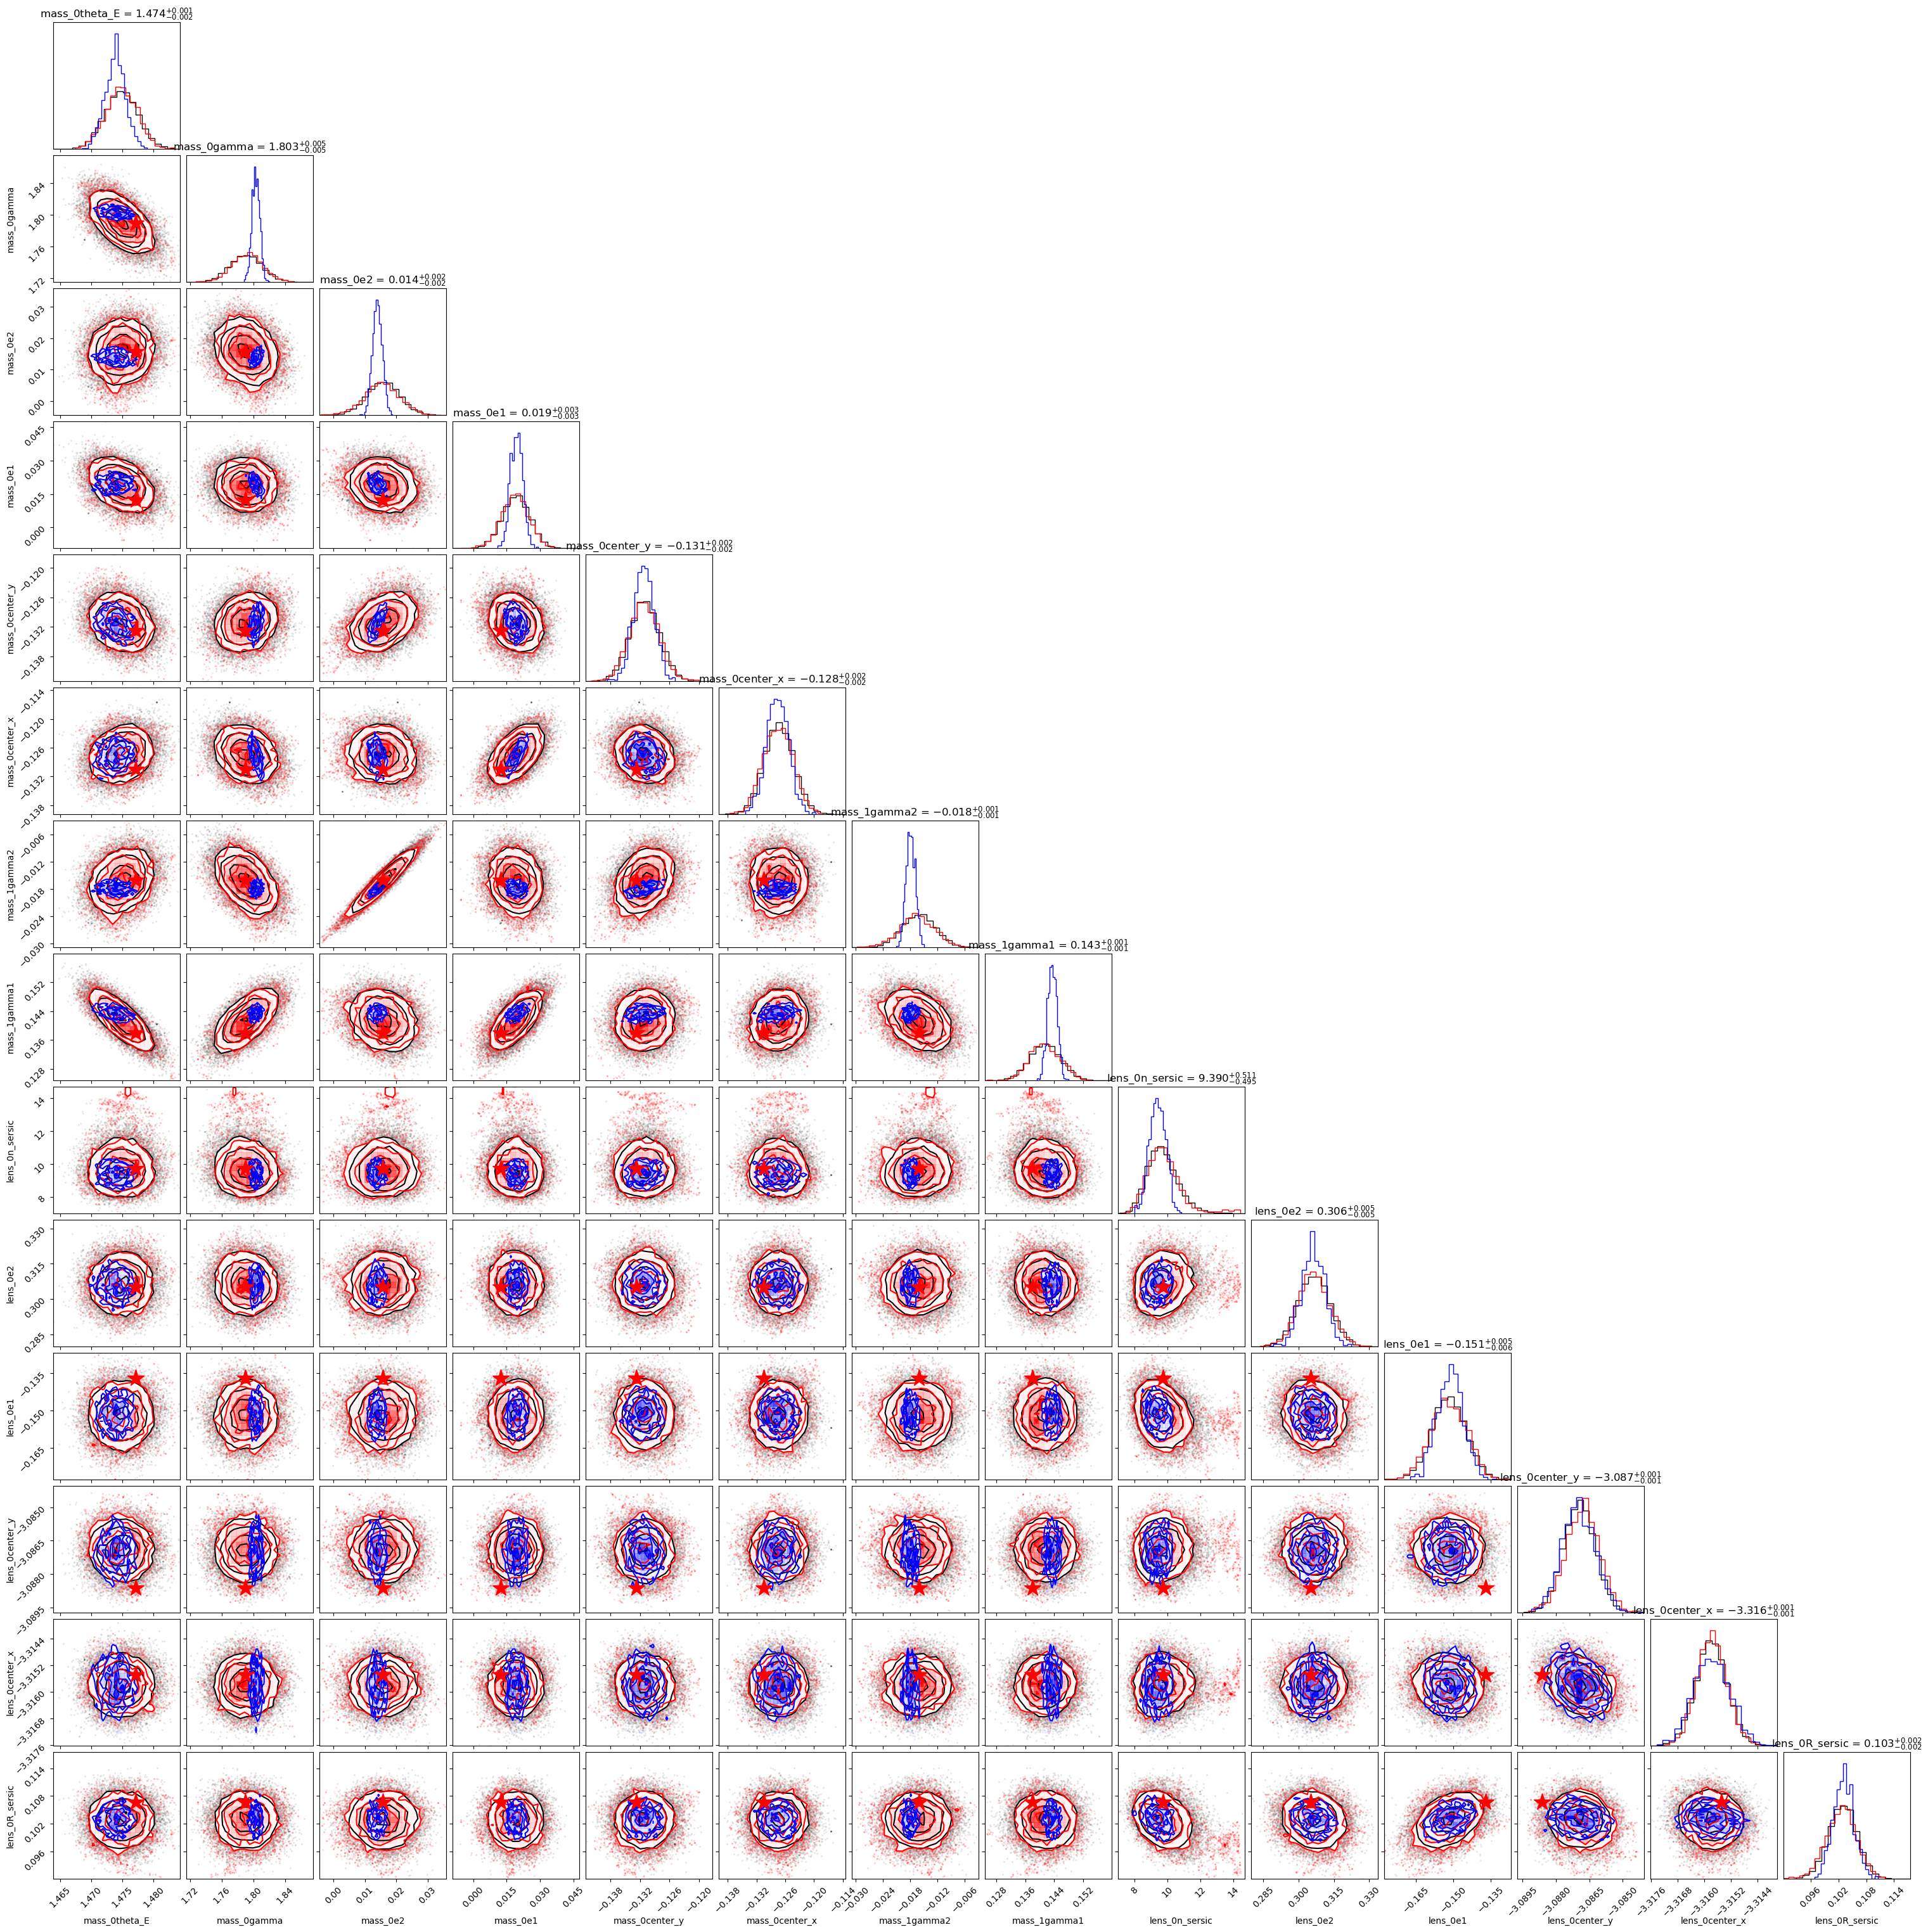

In [44]:
samples = single_chain_samples
samples = samples.reshape(-1, samples.shape[-1]) #samples_mclmc 
MCMC_x = prob_model.bij.forward(list(samples.T))

HMC_x = prob_model.bij.forward(list(hmc_samples.reshape(-1, hmc_samples.shape[-1]).T))

adapt_cov = blackjax_mclmc_sampler_params.inverse_mass_matrix
adapt_qz = tfd.MultivariateNormalFullCovariance(loc=jnp.mean(samples, axis=0), covariance_matrix=adapt_cov)
adapt_qz_samples = adapt_qz.sample((1000,), run_key)
adapt_qz_x = prob_model.bij.forward(list(adapt_qz_samples.T))

svi_samples = qz.sample((1000,), run_key)
svi_x = prob_model.bij.forward(list(svi_samples.T))

# HMC_1chain_x = prob_model.bij.forward(list(results['HMC'].HMC_samples_z[0, 11, -40000:].T))

plot_params = cornerplot_labels(MCMC_x)[:14] #! Only plot some params for speed. CHANGE LATER

n_samp = HMC_x[0][0]['e1'].shape[0]
rand_idx = np.random.choice(np.arange(n_samp), size=(20000,), replace=False)

fig = cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx], HMC_x), color='black',plot_params=plot_params)

n_samp_MCMC = MCMC_x[0][0]['e1'].shape[0]
rand_idx_MCMC = np.random.choice(np.arange(n_samp_MCMC), size=(20000,), replace=True)
cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx_MCMC], MCMC_x), color='red',plot_params=plot_params, fig=fig)

chain_start = prob_model.bij.forward(list(blackjax_state_after_tuning.position))
cornerplot_posterior(svi_x, color='blue', plot_params=plot_params, fig=fig, overplots=chain_start)
# cornerplot_posterior(adapt_qz_x, fig=fig, color='purple')
# cornerplot_posterior(mclmc_results_100sys.HMC_samples, fig=fig, color='purple', plot_params=plot_params)
# cornerplot_posterior(HMC_1chain_x, fig=fig, color='green', plot_params=plot_params)
plt.show()

In [86]:
egval, egvec = jnp.linalg.eig(adapt_cov)

In [87]:
egval

Array([2.10453421e-02+0.j, 2.03757603e-02+0.j, 8.43444094e-03+0.j,
       5.04266704e-03+0.j, 4.23819711e-03+0.j, 2.62749707e-03+0.j,
       9.91778914e-04+0.j, 8.77709943e-04+0.j, 7.37061317e-04+0.j,
       6.04708097e-04+0.j, 5.54775586e-04+0.j, 4.97803849e-04+0.j,
       3.41999956e-04+0.j, 3.10357078e-04+0.j, 2.73336685e-04+0.j,
       2.16185072e-04+0.j, 1.84443663e-04+0.j, 9.89721520e-05+0.j,
       8.58387502e-05+0.j, 8.16472239e-05+0.j, 4.62227545e-05+0.j,
       3.39954167e-05+0.j, 1.24988046e-05+0.j, 8.32604837e-06+0.j,
       6.52492145e-06+0.j, 3.85340718e-06+0.j, 3.59795649e-06+0.j,
       2.05623428e-06+0.j, 1.16555145e-06+0.j, 6.85786290e-07+0.j,
       5.90399509e-07+0.j, 5.32548370e-07+0.j, 1.02394054e-07+0.j,
       1.90983030e-07+0.j, 2.85903923e-07+0.j, 2.66462905e-07+0.j,
       2.23376773e-07+0.j, 2.37112062e-07+0.j], dtype=complex64)

In [88]:
adapt_qz.covariance()

Array([[ 5.3439871e-06, -7.3909723e-07,  3.7002261e-05, ...,
         1.9594620e-05,  5.4189441e-06, -1.4920835e-05],
       [-7.3909723e-07,  4.4642479e-06, -1.2276083e-05, ...,
         1.3272127e-05, -2.3487777e-05, -2.0977448e-05],
       [ 3.7002261e-05, -1.2276083e-05,  3.4668474e-04, ...,
         9.9791643e-05,  8.5930624e-05, -6.7903835e-05],
       ...,
       [ 1.9594620e-05,  1.3272127e-05,  9.9791643e-05, ...,
         8.2266098e-03, -1.0099047e-03, -1.2249177e-03],
       [ 5.4189441e-06, -2.3487777e-05,  8.5930624e-05, ...,
        -1.0099047e-03,  5.3639109e-03,  1.9840915e-03],
       [-1.4920835e-05, -2.0977448e-05, -6.7903835e-05, ...,
        -1.2249177e-03,  1.9840915e-03,  2.0043708e-02]], dtype=float32)